# 📦 Inventory Risk Decision System  
Prioritizing high-risk inventory to prevent stockouts

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
# Load data
transactions_data = pd.read_csv("../data/transactions.csv")
inventory_data = pd.read_csv("../data/inventory_master.csv")

In [3]:
# Clean data
issues = transactions_data[transactions_data.transaction_type=="issue"]
receipts = transactions_data[transactions_data.transaction_type=="receipt"]

issues_sum = issues.groupby("part_number")["qty"].sum()
receipts_sum = receipts.groupby("part_number")["qty"].sum()

inventory_data["issues"] = inventory_data.part_number.map(issues_sum).fillna(0)
inventory_data["receipts"] = inventory_data.part_number.map(receipts_sum).fillna(0)
inventory_data["on_hand"] = inventory_data["receipts"] - inventory_data["issues"]

daily_demand = issues.groupby("part_number")["qty"].mean()

inventory_data["avg_demand"] = inventory_data.part_number.map(daily_demand)
inventory_data["days_of_supply"] = inventory_data["on_hand"] / inventory_data["avg_demand"]
inventory_data["inventory_value"] = inventory_data["on_hand"] * inventory_data["unit_cost"]

inventory_data["recommended_order"] = (
    inventory_data["reorder_point"] +
    inventory_data["safety_stock"] -
    inventory_data["on_hand"]
)

inventory_data["recommended_order"] = inventory_data["recommended_order"].clip(lower=0)

In [4]:
inventory_data.head()

,part_number,category,supplier,unit_cost,lead_time_days,reorder_point,safety_stock,issues,receipts,on_hand,avg_demand,days_of_supply,inventory_value,recommended_order
0,P0000,Fasteners,BoltCo,119.68,11,34,17,37,311.0,274.0,3.700000,74.054054,32792.32,0.0
1,P0001,Electronics,MotionSupply,24.25,25,94,20,38,109.0,71.0,4.750000,14.947368,1721.75,43.0
2,P0002,Bearings,MotionSupply,50.72,28,123,33,40,1176.0,1136.0,5.000000,227.200000,57617.92,0.0
3,P0003,Fasteners,BoltCo,4.07,7,21,33,52,234.0,182.0,3.058824,59.500000,740.74,0.0
4,P0004,Hydraulics,HydroWorks,140.84,16,149,30,74,885.0,811.0,4.111111,197.270270,114221.24,0.0


## Exploratory Data Analysis

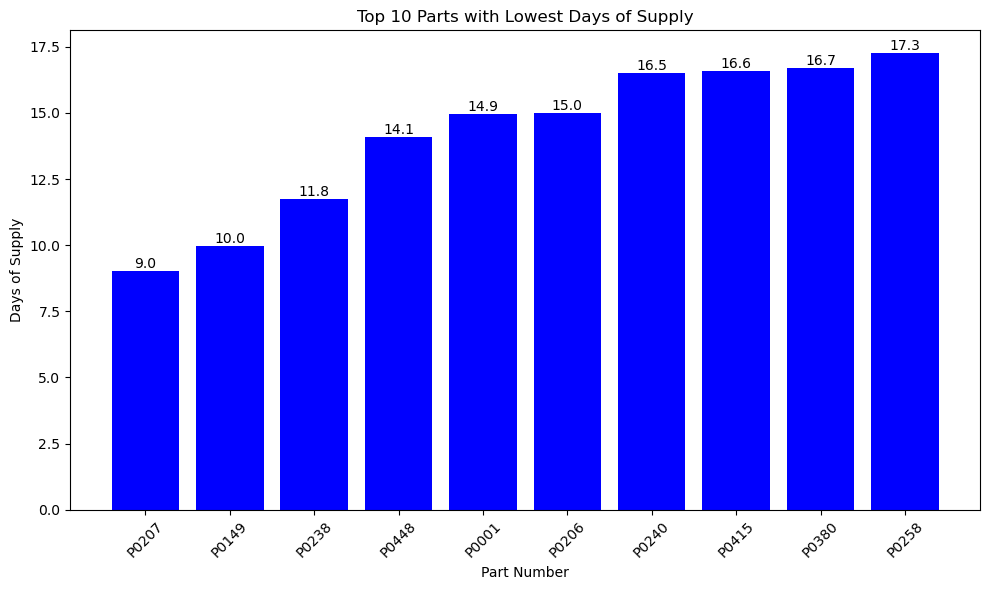

In [5]:
# Top 10 lowest days of supply
top_risk = inventory_data[inventory_data["on_hand"] > 0].sort_values("days_of_supply").head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_risk["part_number"], top_risk["days_of_supply"], color = "blue")
plt.title("Top 10 Parts with Lowest Days of Supply")
plt.xlabel("Part Number")
plt.ylabel("Days of Supply")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}",
             ha="center", va="bottom")
    
plt.tight_layout()
plt.savefig("../outputs/top_10_lowest_days_of_supply.png", dpi=300, bbox_inches="tight")
plt.show()

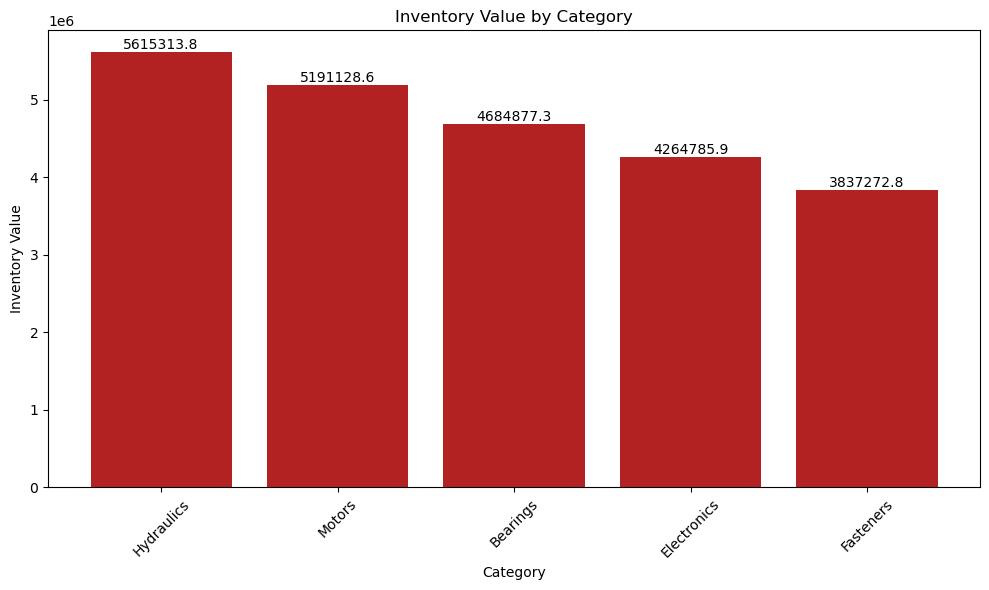

In [6]:
# Inventory value by category
category_value = inventory_data.groupby("category")["inventory_value"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(category_value.index, category_value.values, color = "firebrick")
plt.title("Inventory Value by Category")
plt.xlabel("Category")
plt.ylabel("Inventory Value")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}",
             ha="center", va="bottom")
    
plt.tight_layout()
plt.savefig("../outputs/inventory_value_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

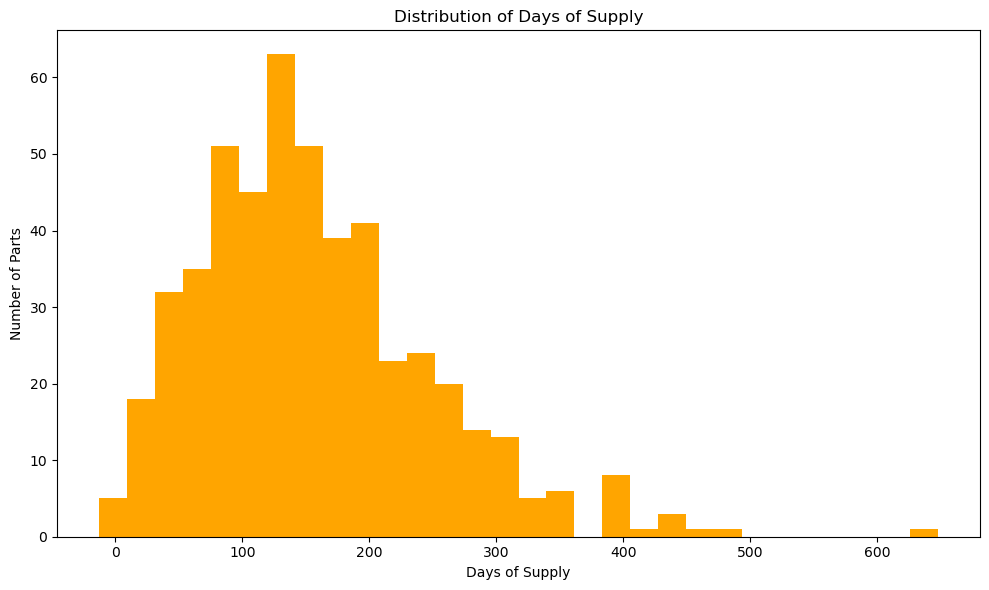

In [7]:
# Days of supply distribution
plt.figure(figsize=(10, 6))
plt.hist(inventory_data["days_of_supply"], bins=30, color = "orange")
plt.title("Distribution of Days of Supply")
plt.xlabel("Days of Supply")
plt.ylabel("Number of Parts")
plt.tight_layout()
plt.savefig("../outputs/days_of_suppy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

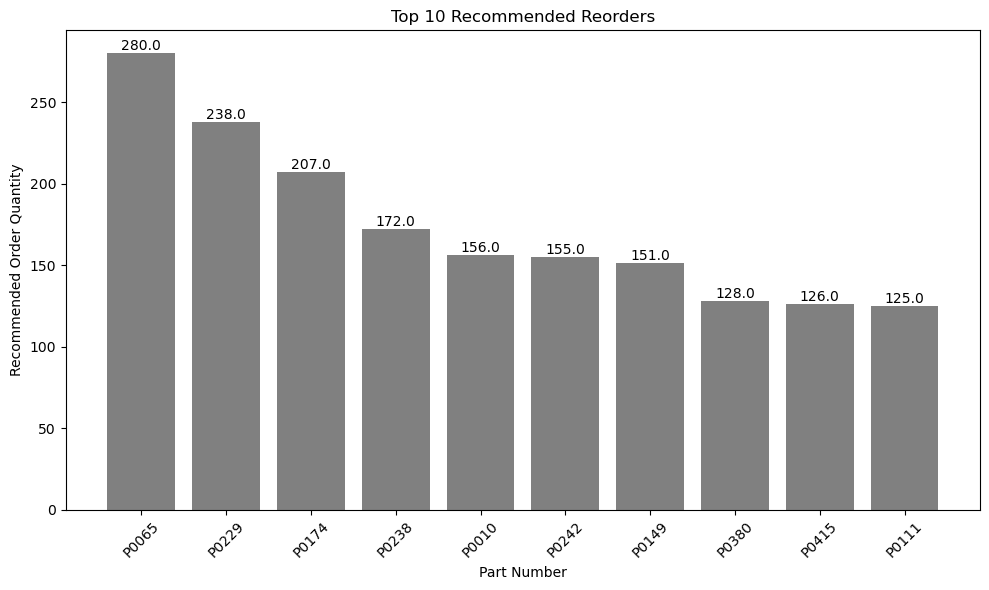

In [8]:
# Recommended reorder quantity for top parts
reorder_parts = inventory_data[inventory_data["recommended_order"] > 0] \
    .sort_values("recommended_order", ascending=False) \
    .head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(reorder_parts["part_number"], reorder_parts["recommended_order"], color = "gray")
plt.title("Top 10 Recommended Reorders")
plt.xlabel("Part Number")
plt.ylabel("Recommended Order Quantity")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}",
             ha="center", va="bottom")
    
plt.tight_layout()
plt.savefig("../outputs/top_reorder_recommendations.png", dpi=300, bbox_inches="tight")
plt.show()

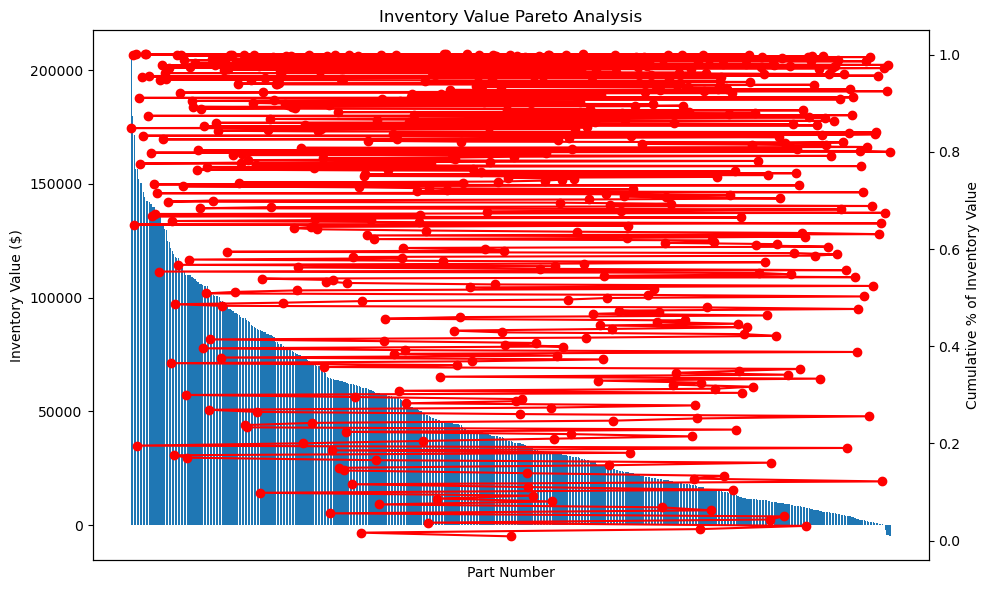

In [9]:
# Pareto
pareto = inventory_data.sort_values("inventory_value", ascending=False)
pareto["cumulative_value"] = pareto["inventory_value"].cumsum()
pareto["cumulative_percent"] = pareto["cumulative_value"] / pareto["inventory_value"].sum()

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(pareto["part_number"], pareto["inventory_value"])
ax1.set_ylabel("Inventory Value ($)")
ax1.set_xlabel("Part Number")

ax2 = ax1.twinx()
ax2.plot(pareto["cumulative_percent"], color="red", marker="o")
ax2.set_ylabel("Cumulative % of Inventory Value")

plt.title("Inventory Value Pareto Analysis")

plt.xticks([])
plt.tight_layout()
plt.savefig("../outputs/inventory_value_pareto.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/xw/bkcm598x3yv0fsx1mxcj11880000gn/T/ipykernel_63767/708778683.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  issues["date"] = pd.to_datetime(issues["date"])


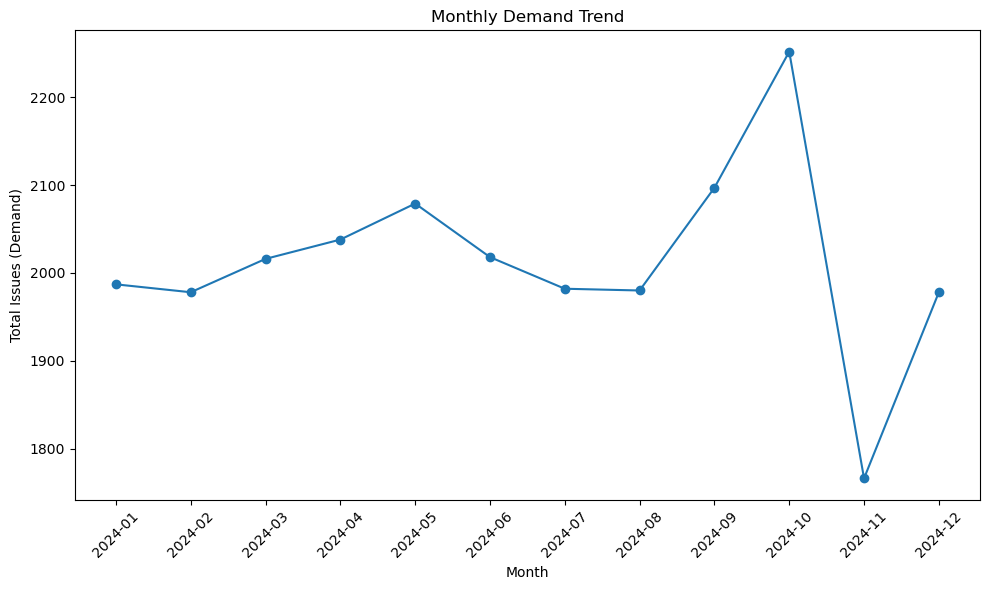

In [10]:
# Demand trend over time
issues = transactions_data[transactions_data["transaction_type"] == "issue"]

issues["date"] = pd.to_datetime(issues["date"])

monthly_demand = issues.groupby(
    issues["date"].dt.to_period("M")
)["qty"].sum()

monthly_demand.index = monthly_demand.index.astype(str)

plt.figure(figsize=(10,6))

plt.plot(monthly_demand.index, monthly_demand.values, marker="o")

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Issues (Demand)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../outputs/demand_trend_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

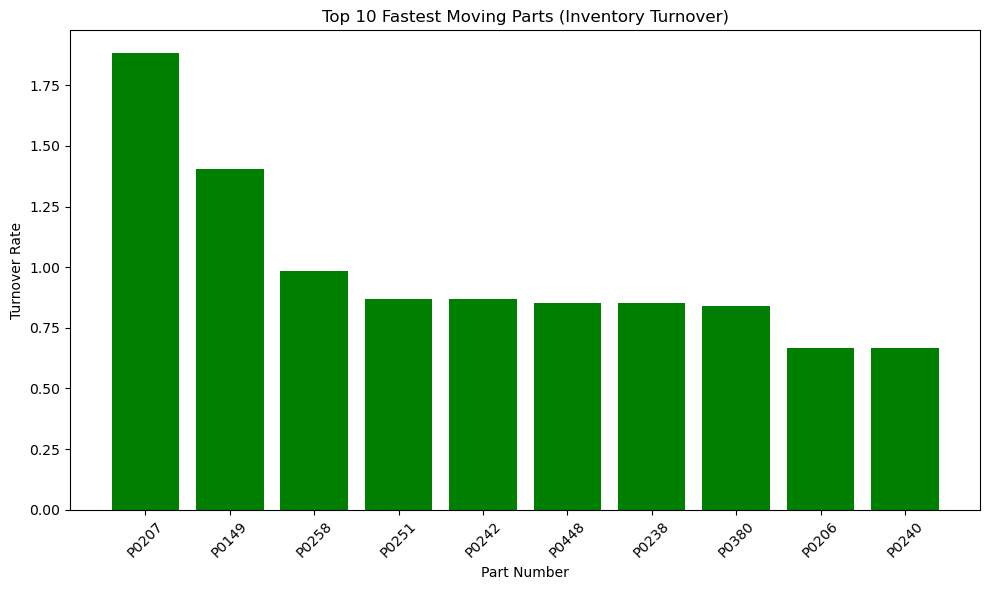

In [11]:
# Inventory turnover
annual_demand = issues.groupby("part_number")["qty"].sum()

inventory_data["annual_demand"] = inventory_data["part_number"].map(annual_demand).fillna(0)
inventory_data["turnover"] = inventory_data["annual_demand"] / inventory_data["on_hand"].replace(0, 1)

turnover_clean = inventory_data[inventory_data["turnover"] > 0]

top_turnover = turnover_clean.sort_values("turnover", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_turnover["part_number"], top_turnover["turnover"], color = "green")
plt.title("Top 10 Fastest Moving Parts (Inventory Turnover)")
plt.xlabel("Part Number")
plt.ylabel("Turnover Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/top_turnover_parts.png", dpi=300, bbox_inches="tight")
plt.show()

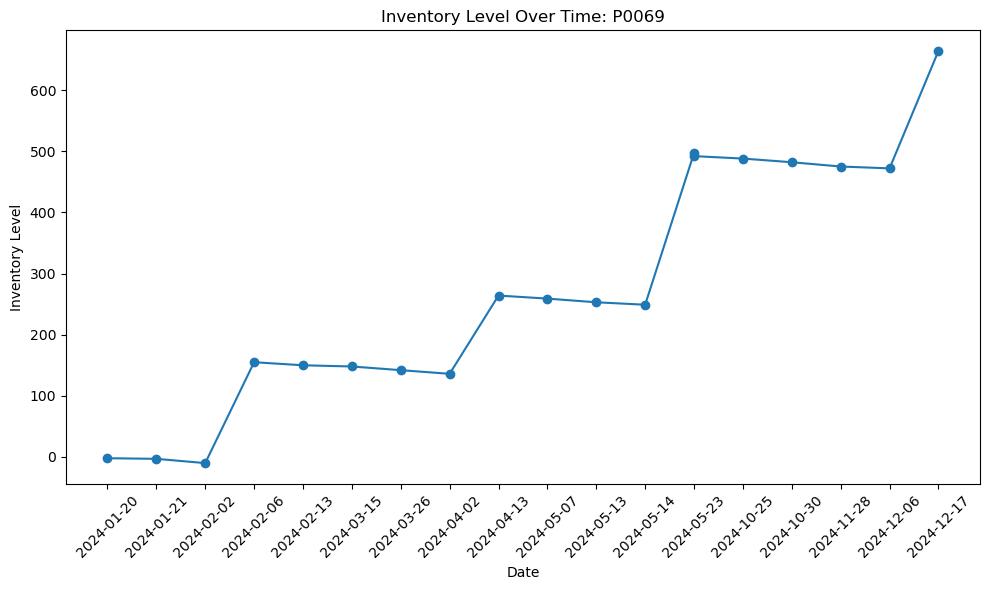

In [12]:
# Running inventory balance
part = inventory_data["part_number"].sample(1, random_state=100).iloc[0]

part_tx = transactions_data[transactions_data["part_number"] == part].copy()
part_tx = part_tx.sort_values("date")
part_tx["inventory_change"] = part_tx.apply(
    lambda row: row["qty"] if row["transaction_type"] == "receipt" else -row["qty"],
    axis=1
)

part_tx["running_inventory"] = part_tx["inventory_change"].cumsum()

plt.figure(figsize=(10,6))
plt.plot(part_tx["date"], part_tx["running_inventory"], marker="o")
plt.title(f"Inventory Level Over Time: {part}")
plt.xlabel("Date")
plt.ylabel("Inventory Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/inventory_level_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

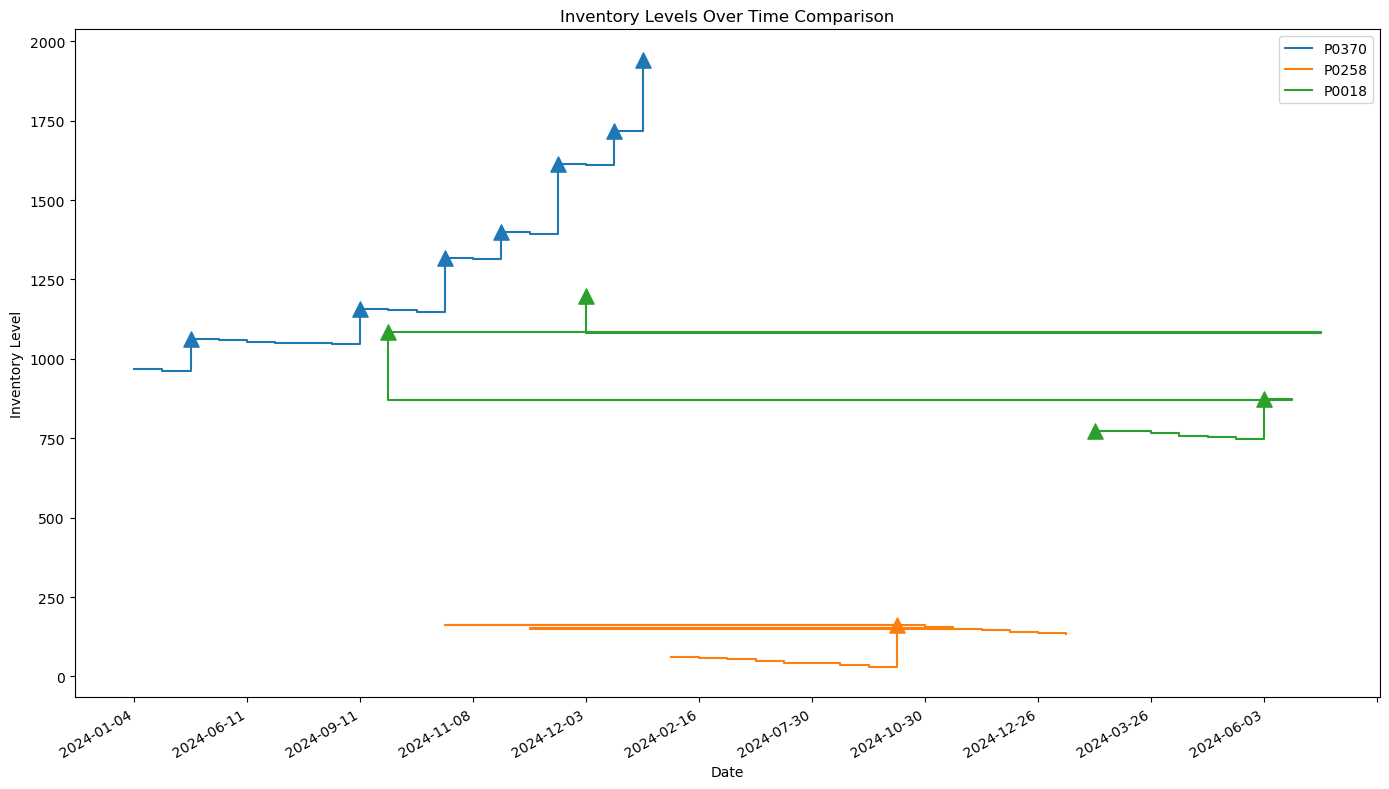

In [13]:
# Inventory levels over time comparison
parts = transactions_data["part_number"].drop_duplicates().sample(3, random_state=100).tolist()
parts = pd.Series(parts)

plt.figure(figsize=(14,8))
for p in parts:
    part_tx = transactions_data[transactions_data["part_number"] == p].copy()
    part_tx = part_tx.sort_values("date")

    part_tx["inventory_change"] = part_tx.apply(
        lambda row: row["qty"] if row["transaction_type"] == "receipt" else -row["qty"],
        axis=1
    )
    starting_inventory = inventory_data.loc[
    inventory_data["part_number"] == p, "on_hand"].values[0]
    
    part_tx["running_inventory"] = starting_inventory + part_tx["inventory_change"].cumsum()
    
    receipts_tx = part_tx[part_tx["transaction_type"] == "receipt"]
    
    plt.step(part_tx["date"], part_tx["running_inventory"], where="post", label=p)
    plt.scatter(receipts_tx["date"], receipts_tx["running_inventory"], marker="^", s=120)

plt.legend()
plt.title("Inventory Levels Over Time Comparison")
plt.xlabel("Date")
plt.ylabel("Inventory Level")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig("../outputs/inventory_levels_over_time_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Stockout risk score
inventory_data["stockout_risk"] = 1 / inventory_data["days_of_supply"].replace(0, 0.01)
inventory_data.loc[inventory_data["days_of_supply"] <= 0, "stockout_risk"] = 5
inventory_data["stockout_risk"] = inventory_data["stockout_risk"].clip(lower=0, upper=5)

inventory_data[["part_number", "days_of_supply", "stockout_risk"]].head()

,part_number,days_of_supply,stockout_risk
0,P0000,74.054054,0.013504
1,P0001,14.947368,0.066901
2,P0002,227.200000,0.004401
3,P0003,59.500000,0.016807
4,P0004,197.270270,0.005069


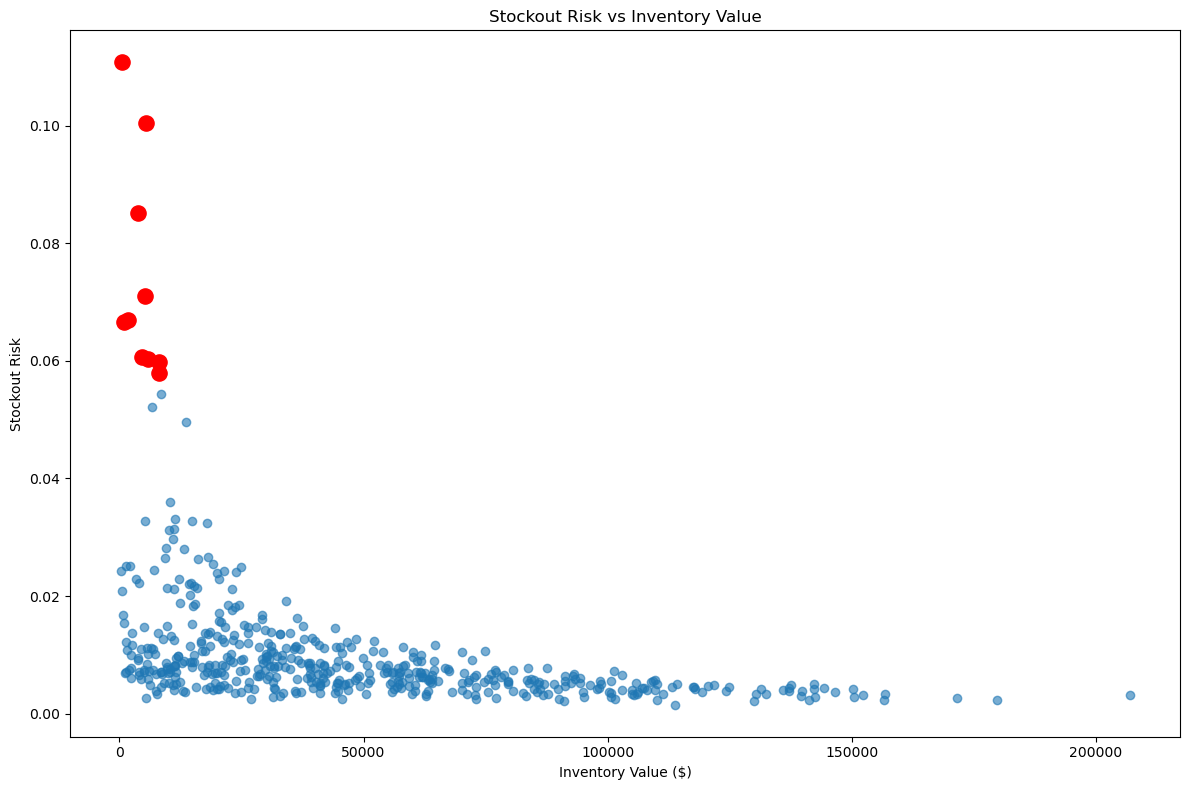

In [15]:
# Stockout risk vs inventory value
inventory_data["stockout_risk"] = inventory_data["stockout_risk"].clip(upper=5)

# Clean data
risk_data = inventory_data[
    (inventory_data["days_of_supply"] > 0) &
    (inventory_data["inventory_value"] > 0)
]

plt.figure(figsize=(12,8))

# All parts
plt.scatter(
    risk_data["inventory_value"],
    risk_data["stockout_risk"],
    alpha=0.6
)

# Highlight highest risk parts
top_risk = risk_data.sort_values("stockout_risk", ascending=False).head(10)

plt.scatter(
    top_risk["inventory_value"],
    top_risk["stockout_risk"],
    color="red",
    s=120
)

plt.title("Stockout Risk vs Inventory Value")
plt.xlabel("Inventory Value ($)")
plt.ylabel("Stockout Risk")

plt.tight_layout()
plt.savefig("../outputs/stockout_risk_vs_inventory_value.png",dpi=300,bbox_inches="tight")
plt.show()

### Key Insights

1. 20% of parts account for 80% of inventory value (Pareto effect).

2. Several high-value parts also have low days of supply,
   creating significant stockout risk.

3. Reorder recommendations highlight parts that could disrupt
   operations if not replenished.

4. Demand analysis shows seasonal patterns in part usage.

## 📦 Data Preparation
Prepare and filter transaction data to analyze demand patterns.

In [16]:
# Prepare transactions
transactions_data["date"] = pd.to_datetime(transactions_data["date"])

issues = transactions_data[transactions_data["transaction_type"] == "issue"]

## ⚙️ Feature Engineering
Create key variables such as daily usage and demand volatility.

In [17]:
# Feature engineering
# Total demand
demand = issues.groupby("part_number")["qty"].sum()

# Time window
num_days = (issues["date"].max() - issues["date"].min()).days

# daily usage
daily_usage = (demand / num_days).reset_index(name="daily_usage")

# Demand volatility
volatility = issues.groupby("part_number")["qty"].std().reset_index(name="demand_std")

## 🔗 Data Integration
Combine inventory data with engineered demand features.

In [18]:
# Merge datasets
inventory = inventory_data.merge(daily_usage, on="part_number", how="left")
inventory = inventory.merge(volatility, on="part_number", how="left")

# Fill missing values
inventory["daily_usage"] = inventory["daily_usage"].fillna(0)
inventory["demand_std"] = inventory["demand_std"].fillna(0)

# Calculate days supply
inventory["calc_days_supply"] = inventory["on_hand"] / inventory["daily_usage"]
inventory["calc_days_supply"] = inventory["calc_days_supply"].replace(np.inf, 999)

## 🤖 Predictive Modeling (Stockout Risk Classification)

In [19]:
# Create a Target Variable
inventory["stockout_flag"] = (inventory["days_of_supply"] < 7).astype(int)

# Select Features
features = [
    "unit_cost",
    "lead_time_days",
    "on_hand",
    "inventory_value",
    "daily_usage",
    "demand_std",
    "stockout_risk"
]

X = inventory[features]
y = inventory["stockout_flag"]

In [20]:
# Train, test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



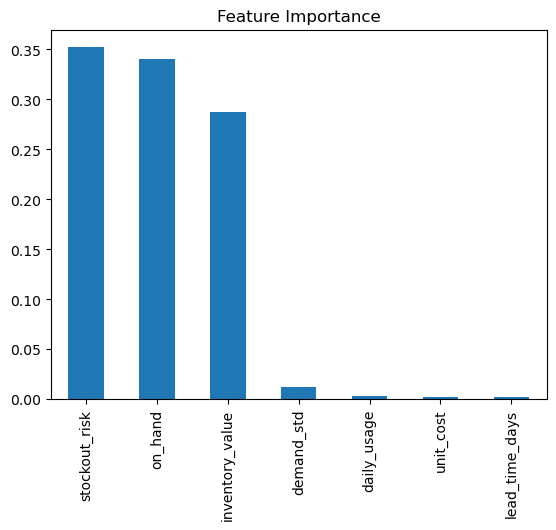

In [22]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar", title="Feature Importance")
plt.savefig("../outputs/feature_importance.png",dpi=300,bbox_inches="tight")
plt.show()

## 📊 Stockout Probability & Financial Risk Analysis
This analysis combines predicted stockout probability with inventory value to identify high-risk, high-impact items that require immediate attention

In [23]:
# Stockout probability
inventory.loc[X_test.index, "stockout_probability"] = model.predict_proba(X_test)[:,1]

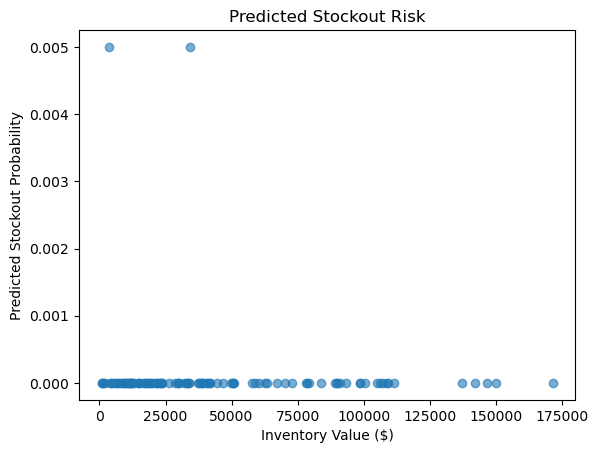

In [24]:
plt.scatter(inventory["inventory_value"], inventory["stockout_probability"], alpha=0.6)
plt.xlabel("Inventory Value ($)")
plt.ylabel("Predicted Stockout Probability")
plt.title("Predicted Stockout Risk")
plt.savefig("../outputs/predicted_stockout_risk.png",dpi=300,bbox_inches="tight")
plt.show()

**Insight:**  
Items with both high inventory value and high predicted stockout probability represent the greatest financial risk and should be prioritized for immediate intervention.

In [25]:
inventory["stockout_flag"].value_counts()

0    496
1      4
Name: stockout_flag, dtype: int64

Since predictive machine learning is unreliable due to extreme class imbalance, a risk scoring framework is developed to prioritize high-risk inventory items

## 🧠 Risk Scoring Model
Assign risk scores based on supply, demand, and lead time conditions.

In [26]:
# Create inventory risk score
inventory["risk_score"] = (
    (inventory["days_of_supply"] < inventory["lead_time_days"]).astype(int) * 3 +
    (inventory["lead_time_days"] > 20).astype(int) * 2 +
    (inventory["daily_usage"] > inventory["daily_usage"].median()).astype(int)
)

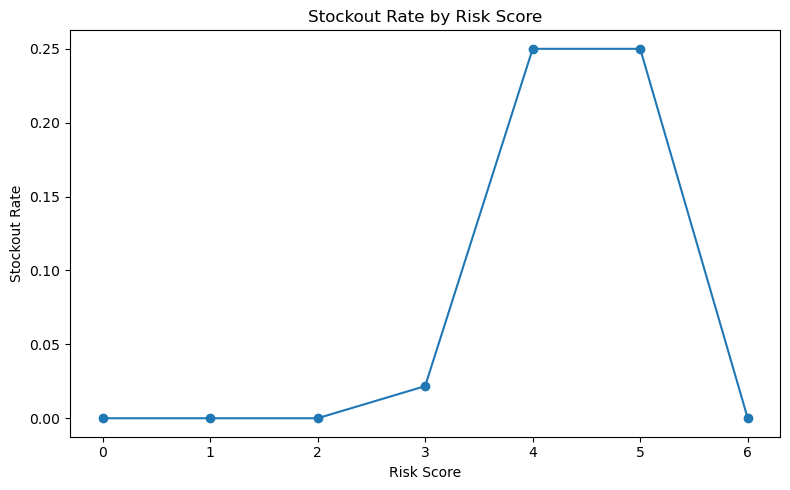

In [27]:
# Risk analysis
risk_analysis = inventory.groupby("risk_score")["stockout_flag"].mean()

plt.figure(figsize=(8,5))
plt.plot(risk_analysis.index, risk_analysis.values, marker='o')

plt.title("Stockout Rate by Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Stockout Rate")

plt.tight_layout()
plt.show()

## 📊 Model Evaluation
Evaluate how effectively the model prioritizes stockout risk.

In [28]:
# Evaluate model
df_sorted = inventory.sort_values(by="risk_score", ascending=False).reset_index(drop=True)

df_sorted["rank_pct"] = df_sorted.index / len(df_sorted)

top_20 = df_sorted[df_sorted["rank_pct"] <= 0.20]

total_stockouts = inventory["stockout_flag"].sum()
captured_stockouts = top_20["stockout_flag"].sum()

capture_rate = captured_stockouts / total_stockouts

In [29]:
print("----- MODEL EVALUATION -----")
print(f"Total Stockouts: {total_stockouts}")
print(f"Stockouts Captured (Top 20%): {captured_stockouts}")
print(f"Capture Rate: {capture_rate:.2%}")

baseline_rate = total_stockouts / len(inventory)
top20_rate = captured_stockouts / len(top_20)

print("\n----- BUSINESS IMPACT -----")
print(f"Baseline Stockout Rate: {baseline_rate:.2%}")
print(f"Top 20% Stockout Rate: {top20_rate:.2%}")
print(f"Lift: {top20_rate / baseline_rate:.2f}x")

print("\nINSIGHT: High-risk items are significantly more likely to stockout.")

----- MODEL EVALUATION -----
Total Stockouts: 4
Stockouts Captured (Top 20%): 4
Capture Rate: 100.00%

----- BUSINESS IMPACT -----
Baseline Stockout Rate: 0.80%
Top 20% Stockout Rate: 3.96%
Lift: 4.95x

INSIGHT: High-risk items are significantly more likely to stockout.


## 🚦 Action Framework
Translate risk scores into operational decisions.

In [30]:
# Create action
def assign_action(score):
    if score >= 4:
        return "Immediate Reorder"
    elif score == 3:
        return "Monitor Closely"
    elif score == 2:
        return "Review"
    else:
        return "Low Priority"
    
inventory["action"] = inventory["risk_score"].apply(assign_action)

## 📈 Visual Insights
Visualize risk distribution and high-priority inventory items

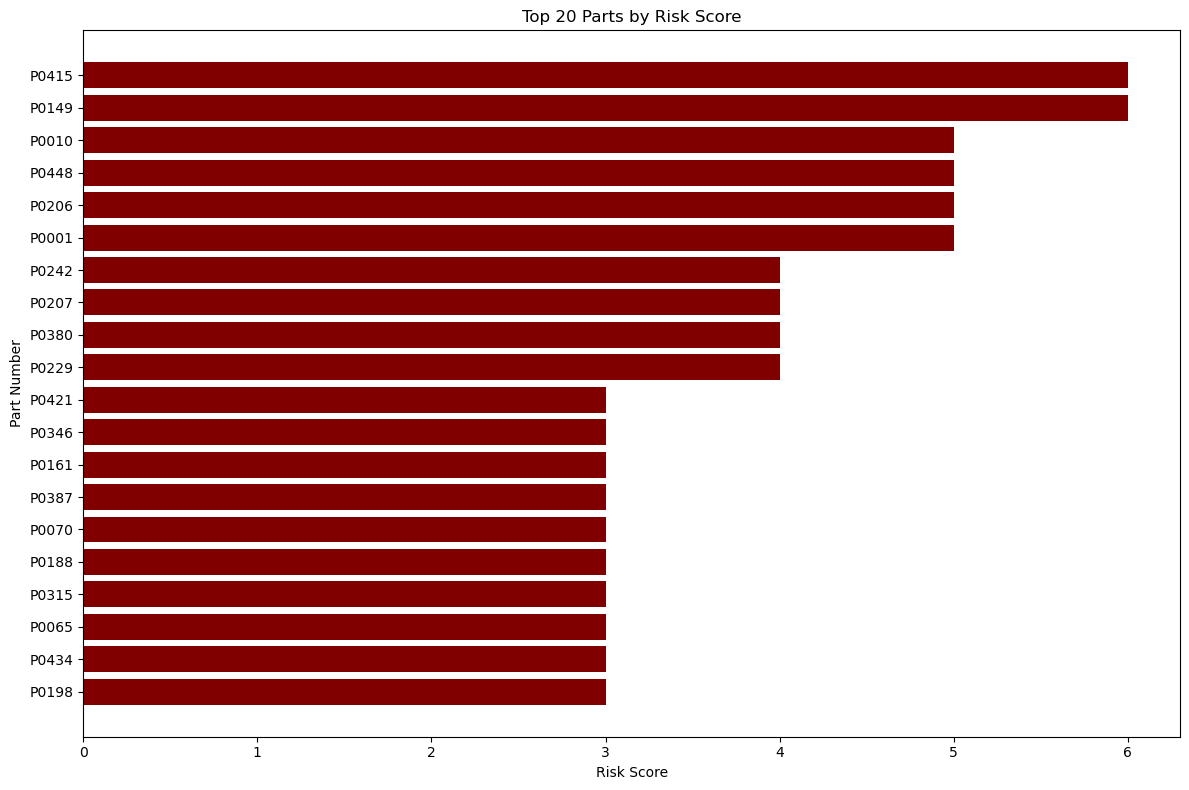

In [31]:
top_risk = inventory.sort_values("risk_score", ascending=True).tail(20)

plt.figure(figsize=(12, 8))
plt.barh(top_risk["part_number"].astype(str), top_risk["risk_score"], color = "maroon")

plt.title("Top 20 Parts by Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Part Number")

plt.tight_layout()
plt.savefig("../outputs/top_20_parts_by_risk_score.png", dpi=300, bbox_inches="tight")
plt.show()

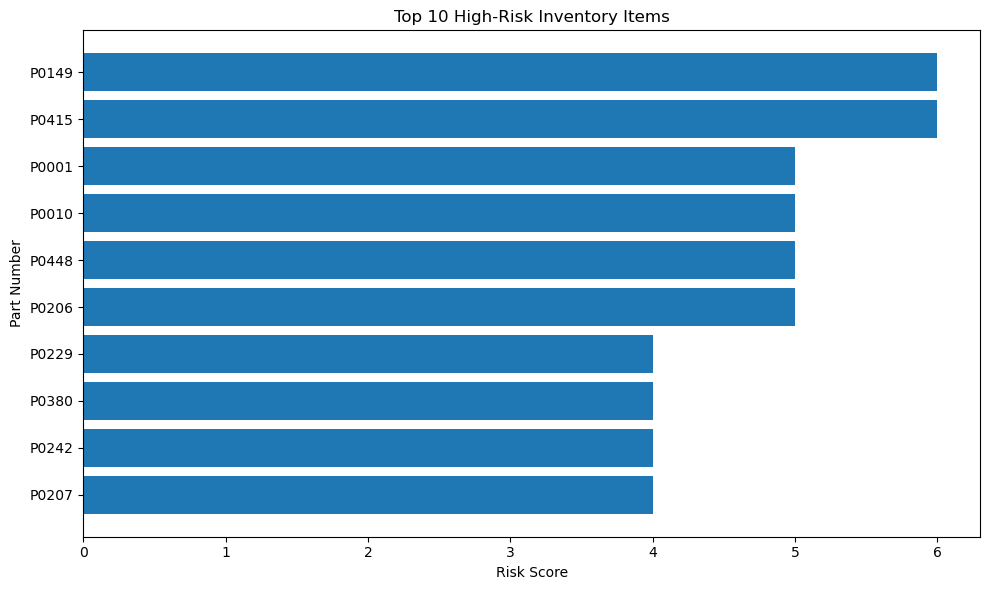

In [32]:
top_10 = inventory.sort_values("risk_score", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10["part_number"], top_10["risk_score"])
plt.title("Top 10 High-Risk Inventory Items")
plt.xlabel("Risk Score")
plt.ylabel("Part Number")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/top_10_high-risk_inventory_items.png", dpi=300, bbox_inches="tight")
plt.show()

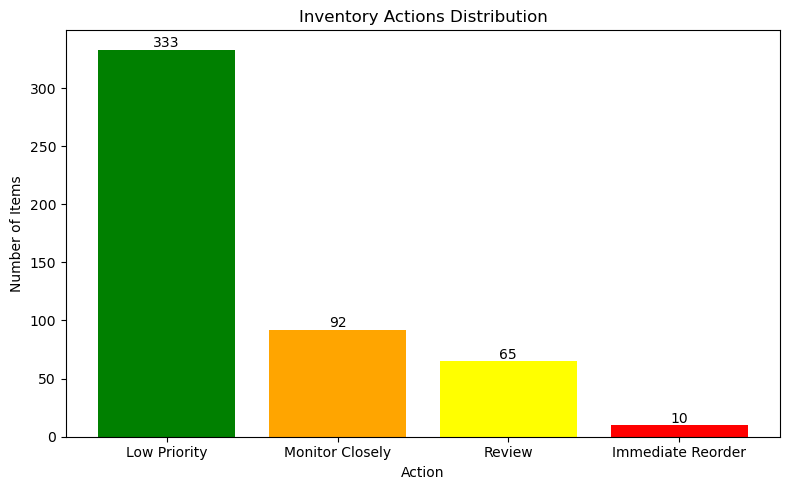

In [33]:
action_counts = inventory["action"].value_counts()

# Define colors per action
color_map = {
    "Low Priority": "green",
    "Review": "yellow",
    "Monitor Closely": "orange",
    "Immediate Reorder": "red"
}

colors = [color_map[action] for action in action_counts.index]

plt.figure(figsize=(8,5))
bars = plt.bar(action_counts.index, action_counts.values, color=colors)

plt.title("Inventory Actions Distribution")
plt.xlabel("Action")
plt.ylabel("Number of Items")
plt.xticks(rotation=0)

# Add labels on top
for i, v in enumerate(action_counts.values):
    plt.text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.savefig("../outputs/inventory_actions_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 🧠 Final Takeaway

This project demonstrates that:

- Data-driven prioritization is more effective than predicting rare events directly
- A simple, interpretable scoring system can outperform complex models in imbalanced scenarios
- Inventory risk can be managed proactively using operational metrics

### 🚀 Key Result:

The model successfully concentrates stockout risk into a small subset of inventory, enabling targeted intervention.